In [5]:
import torch
import matplotlib.pyplot as plt
import numpy as np

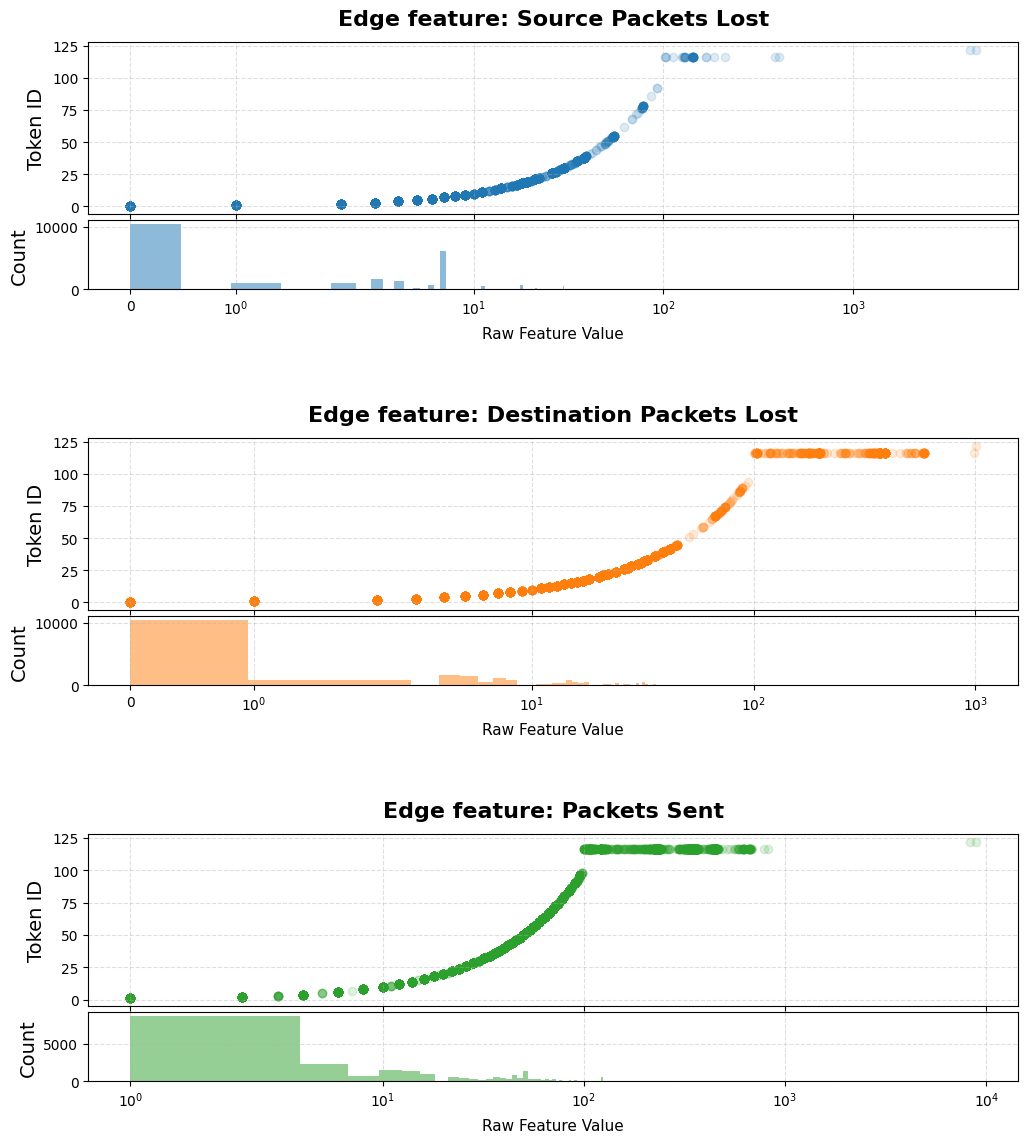

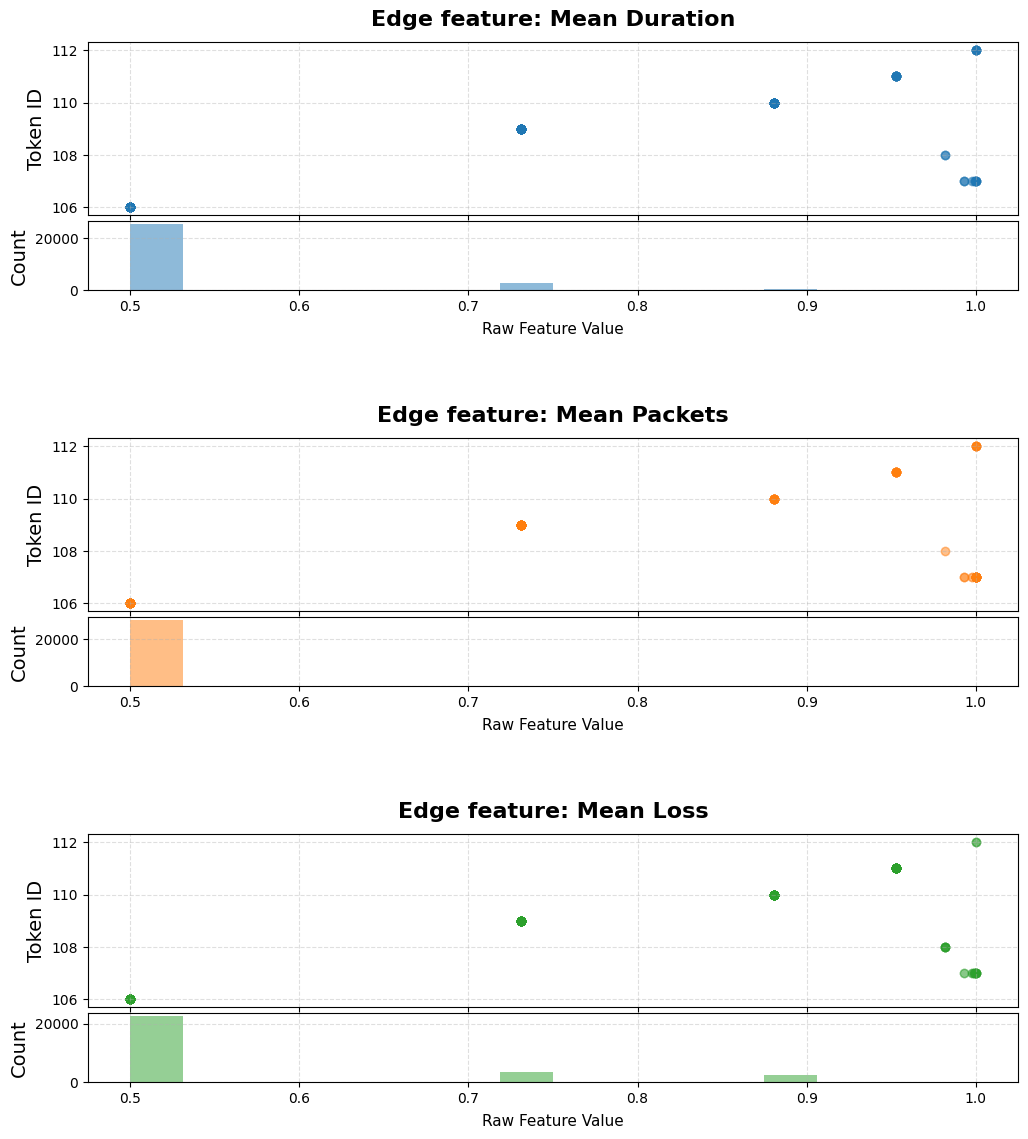

In [7]:
def show_feats(f, st=0, en=-1, features=None):
    # Load both tensors (adjust loading logic if your tokens are stored differently)
    g = torch.load(f, weights_only=False)
    raw_np = g.raw_edge_attr[::100, st:en].numpy()
    token_np = g.edge_attr[::100, st:en].numpy()

    B, d = raw_np.shape

    # Base height per feature group
    fig = plt.figure(figsize=(12, 4.5 * d))

    # 1. Outer grid: Controls the large spacing BETWEEN different features
    outer_gs = fig.add_gridspec(nrows=d, ncols=1, hspace=0.6)

    for i in range(d):
        x = raw_np[:, i]
        y = token_np[:, i]
        use_symlog = x.max() > 100

        # 2. Inner grid: Controls the tight spacing BETWEEN the scatter and hist
        # hspace=0.05 sets a very small gap between them
        inner_gs = outer_gs[i].subgridspec(nrows=2, ncols=1, height_ratios=[2.5, 1], hspace=0.05)

        # ----------------------------------------------------
        # Top Subplot: Scatter Plot
        # ----------------------------------------------------
        ax_scatter = fig.add_subplot(inner_gs[0])
        ax_scatter.scatter(x, y, alpha=0.15,  color=f'C{i}')
        ax_scatter.set_ylabel('Token ID', fontsize=14)

        # Title pushed up slightly using pad
        if not features:
            feat = str(i)
        else:
            feat = features[i]

        ax_scatter.set_title("Edge feature: " + feat,
                             fontsize=16, fontweight='bold', pad=12)
        ax_scatter.grid(True, linestyle='--', alpha=0.4)

        # ----------------------------------------------------
        # Bottom Subplot: Density Histogram (Shared X-Axis)
        # ----------------------------------------------------
        ax_hist = fig.add_subplot(inner_gs[1], sharex=ax_scatter)
        ax_hist.hist(x, bins='auto', color=f'C{i}', alpha=0.5, log=False)
        ax_hist.set_ylabel('Count', fontsize=14)
        ax_hist.grid(True, linestyle='--', alpha=0.4)

        # Apply scaling rules uniformly
        if use_symlog:
            ax_scatter.set_xscale('symlog')
            ax_hist.set_xscale('symlog')

        ax_hist.set_xlabel(f'Raw Feature Value', fontsize=11, labelpad=6)

        # Hide the x-axis tick labels for the top scatter plot so they don't blend into the hist
        plt.setp(ax_scatter.get_xticklabels(), visible=False)

    # Note: We avoid aggressive tight_layout here so it doesn't break the subgridspec structure
    plt.show()

show_feats('../data/unsw_tgraph_csr_raw.pt', st=3, en=7, features=['Source Packets Lost', 'Destination Packets Lost', 'Packets Sent'])
show_feats('../data/lanl14argus_tgraph_raw_csr.pt', en=3, features=['Mean Duration', 'Mean Packets', 'Mean Loss'])

In [ ]:
g = torch.load('../data/lanl14argus_tgraph_raw_csr.pt', weights_only=False)
g.raw_edge_attr.unique().size()

torch.Size([19])

: 